In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import joblib

In [2]:
x_train=pd.read_csv("../data/X_train.csv")
x_test=pd.read_csv("../data/X_test.csv")
y_train=pd.read_csv("../data/y_train.csv").squeeze()
y_test=pd.read_csv("../data/y_test.csv").squeeze()

In [3]:
print(f"x_train = {x_train.shape}")
print(f"x_test ={x_test.shape}")
print(f"y_train ={y_train.shape}")
print(f"y_test ={y_test.shape}")
print( y_train.value_counts())

x_train = (179048, 21)
x_test =(24053, 21)
y_train =(179048,)
y_test =(24053,)
SeriousDlqin2yrs
0    89524
1    89524
Name: count, dtype: int64


In [4]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred=rf_model.predict(x_test)
y_prob=rf_model.predict_proba(x_test)[:, 1]


In [6]:
print(classification_report(y_test, y_pred,
      target_names=["Not Default", "Default"]))

# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")
print("\nROC-AUC interpretation:")
print("  0.5 = random guessing (useless)")
print("  0.7 = acceptable")
print("  0.8 = good")
print("  0.9 = excellent")
print(f"  Our model: {auc:.4f}")

              precision    recall  f1-score   support

 Not Default       0.96      0.92      0.94     22382
     Default       0.32      0.50      0.39      1671

    accuracy                           0.89     24053
   macro avg       0.64      0.71      0.66     24053
weighted avg       0.92      0.89      0.90     24053

ROC-AUC Score: 0.8330

ROC-AUC interpretation:
  0.5 = random guessing (useless)
  0.7 = acceptable
  0.8 = good
  0.9 = excellent
  Our model: 0.8330


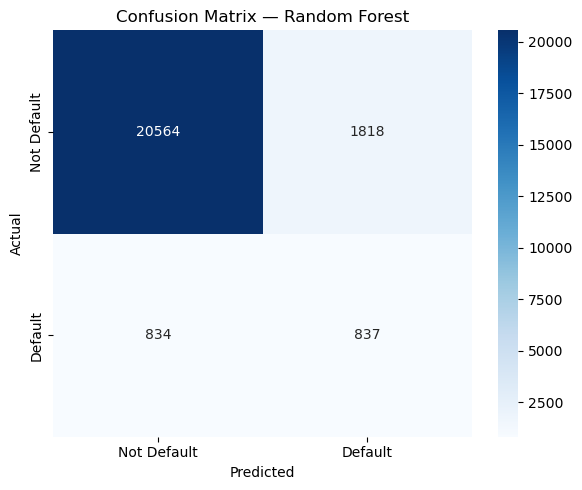


True Negatives  (correctly said not default): 20,564
False Positives (wrongly said default)       : 1,818
False Negatives (missed actual defaults)     : 834
True Positives  (correctly caught defaults)  : 837


In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Default", "Default"],
    yticklabels=["Not Default", "Default"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("../outputs/day6_confusion_matrix.png")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly said not default): {tn:,}")
print(f"False Positives (wrongly said default)       : {fp:,}")
print(f"False Negatives (missed actual defaults)     : {fn:,}")
print(f"True Positives  (correctly caught defaults)  : {tp:,}")

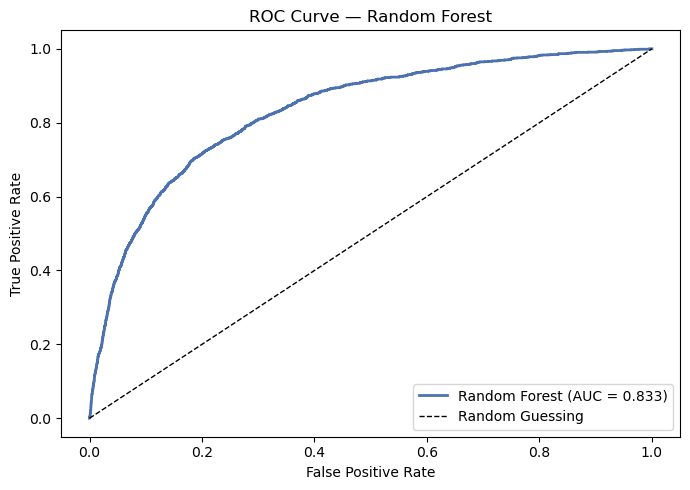

ROC curve saved!


In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#4C72B0", lw=2,
         label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/day6_roc_curve.png")
plt.show()
print("ROC curve saved!")

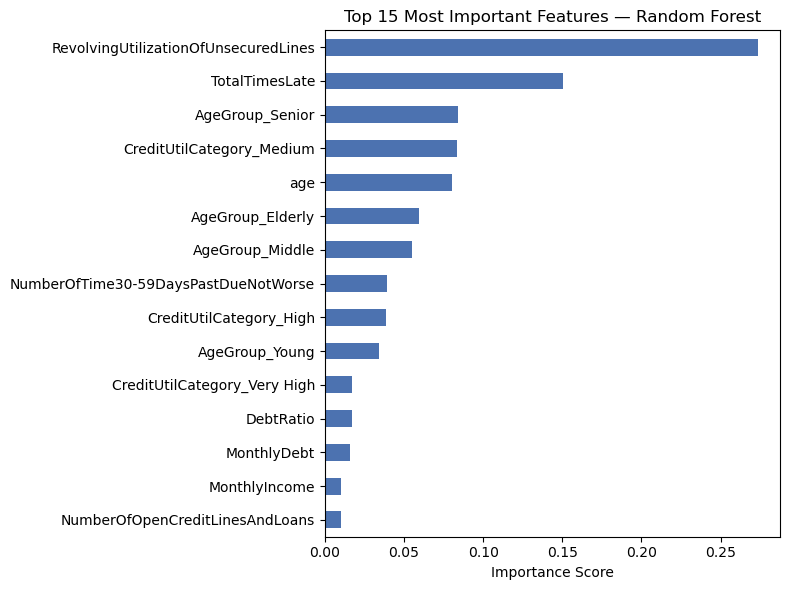


Top 5 most important features:
RevolvingUtilizationOfUnsecuredLines    0.273803
TotalTimesLate                          0.150171
AgeGroup_Senior                         0.084251
CreditUtilCategory_Medium               0.083253
age                                     0.080048
dtype: float64


In [9]:

importances = pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#4C72B0")
plt.xlabel("Importance Score")
plt.title("Top 15 Most Important Features — Random Forest")
plt.tight_layout()
plt.savefig("../outputs/day6_feature_importance.png")
plt.show()

print("\nTop 5 most important features:")
print(importances.tail(5).sort_values(ascending=False))

In [10]:

import os
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/random_forest_model.pkl")
print("Model saved to models/random_forest_model.pkl")
scores = {
    "model": "Random Forest",
    "roc_auc": round(auc, 4),
}
print(f"\nDay 6 complete!")
print(f"Random Forest ROC-AUC: {auc:.4f}")

Model saved to models/random_forest_model.pkl

Day 6 complete!
Random Forest ROC-AUC: 0.8330
